In [1]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import xgboost as xgb 
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
)
from src.processing import Processing
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import os
import gc
from tfrecordimagehandler import TFRecordImageHandler
from src.balance import split_data_nested_cv_ts, split_data, drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, ensemble_sample_and_merge

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(image_batch, group_name_batch, num_samples=4):
    plt.figure(figsize=(10, num_samples * 3))

    for i in range(num_samples):
        # Primer canal: la imagen en escala de grises
        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.imshow(np.squeeze(image_batch[i, :, :, 0]), cmap='gray')  # Primer canal
        plt.title(f"Image (Group: {group_name_batch[i].numpy()})")
        plt.axis('off')

        # Segundo canal: la máscara
        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.imshow(np.squeeze(image_batch[i, :, :, 1]), cmap='gray')  # Segundo canal
        plt.title(f"Mask (Group: {group_name_batch[i].numpy()})")
        plt.axis('off')

    plt.show()

In [3]:
# Definir hiperparámetros
INPUT_DIR = 'input/tfrecord_dataset'
batch_size = 32
n_epochs = 10
checkpoint = './best_model_vgg.h5'
shuffle = True
verbose = 1

Images min: -0.09087073802947998, max: 1.0986453294754028


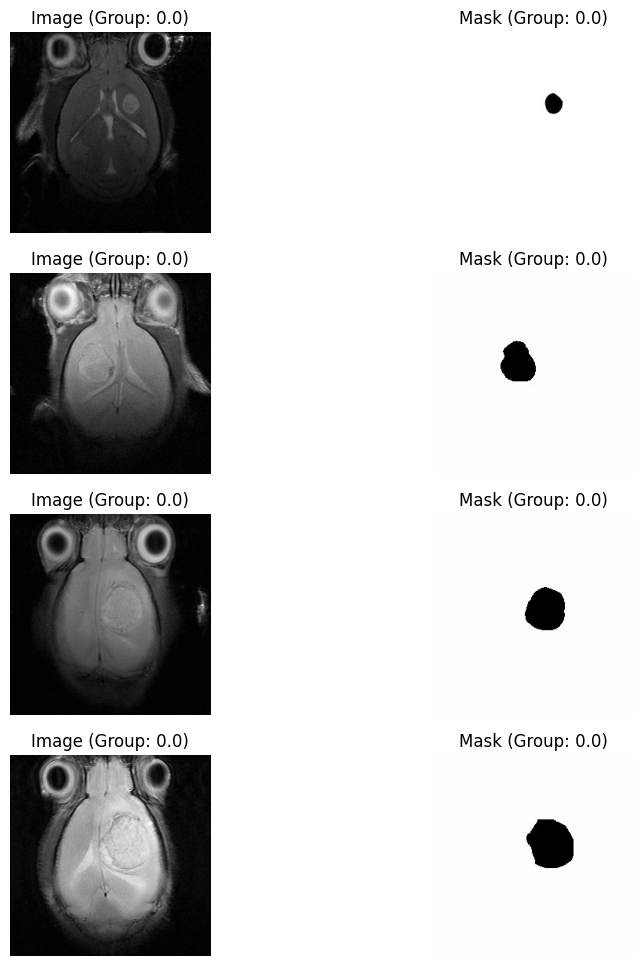

In [4]:
train_tfrefcord = os.path.join(INPUT_DIR, 'full_ds.tfrecord')
ds_handler = TFRecordImageHandler(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=True)
ds = ds_handler.dataset
#images_tf, masks_tf, group_name_batches, mouse_id_batches, day_of_study_batches = next(iter(train_ds.dataset))

images_tf, group_name_batches = next(iter(ds))
# Check if images are normalized
print(f"Images min: {images_tf.numpy().min()}, max: {images_tf.numpy().max()}")

# visualize_data(images_tf, masks_tf, group_name_batches, mouse_id_batches, day_of_study_batches, num_samples=4)
visualize_data(images_tf, group_name_batches, num_samples=4)

Number of data used to train:
Train: 384


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,241,474 (58.14 MB)

 Trainable params: 527,362 (2.01 MB)

 Non-trainable params: 14,714,112 (56.13 MB)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6754 - loss: 0.6867 - val_accuracy: 1.0000 - val_loss: 0.6274
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7764 - loss: 0.6520 - val_accuracy: 1.0000 - val_loss: 0.5561
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7764 - loss: 0.6170 - val_accuracy: 1.0000 - val_loss: 0.4788
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.7764 - loss: 0.5872 - val_accuracy: 1.0000 - val_loss: 0.4062
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.7764 - loss: 0.5620 - val_accuracy: 1.0000 - val_loss: 0.3504
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7764 - loss: 0.5461 - val_accuracy: 1.0000 - val_loss: 0.3109
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7764 - loss: 0.5387 - val_accuracy: 1.0000 - val_loss: 0.2855
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7764 - loss: 0.5357 - val_accuracy: 1.0000 - val_loss: 0.2700
Epoch 9/

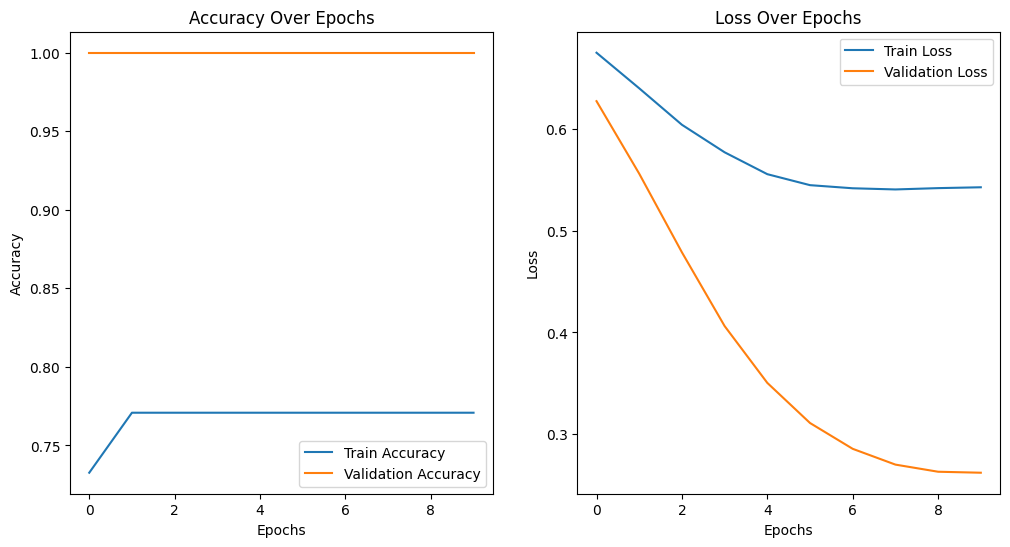

ValueError: No such layer: block5_conv3. Existing layers are: ['vgg16', 'global_average_pooling2d', 'dense', 'dropout', 'dense_1'].

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import cv2

# Define your dataset and batch size (assuming `ds` is the dataset object)
print('Number of data used to train:')
print('Train:', len(list(ds) * batch_size))

# Create a VGG16 model with 2 input channels
base_model = VGG16(weights=None, include_top=False, input_shape=(256, 256, 2))

# Freeze the base model layers
base_model.trainable = False

# Create the classification head of the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Global average pooling layer
    layers.Dense(1024, activation='relu'),  # Dense layer with 1024 units
    layers.Dropout(0.5),  # Dropout for regularization
    layers.Dense(2, activation='softmax')  # Output layer for 2 classes
])

# Compile the model with sparse categorical cross-entropy loss
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# TensorBoard callback for visualization
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir='./logs/vgg')

# Early stopping callback to stop training if validation accuracy doesn't improve
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Show the model summary
model.summary()

# Split the dataset into training and validation sets (adjust accordingly)
train_size = int(0.8 * len(list(ds)))  # 80% for training, 20% for validation
train_ds = ds.take(train_size)
val_ds = ds.skip(train_size)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=n_epochs,
    verbose=verbose,
    callbacks=[tensorboard_callback, early_stopping]
)

# Visualization of training and validation loss/accuracy
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()

# Function for generating CAM (Class Activation Map)
def generate_cam(model, image, class_idx):
    # Get the final convolutional layer in VGG16
    last_conv_layer = model.get_layer('block5_conv3')

    # Create a model that maps the input image to the final convolutional layer's output and the model's predictions
    grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        # Watch the image
        tape.watch(image)
        conv_output, predictions = grad_model(image)
        class_channel = predictions[:, class_idx]

    # Get the gradient of the class output value with respect to the feature map
    grads = tape.gradient(class_channel, conv_output)

    # Global average pooling to get the weights of the feature maps
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply the feature maps by the weights (pooled grads) and take the mean across all the channels
    conv_output = conv_output[0]
    cam = np.dot(conv_output, pooled_grads)

    # Rescale the CAM to the same size as the image
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (256, 256))
    cam = cam / cam.max()

    return cam

# Visualize CAM for a sample image from the validation set
# Assuming `image` is a batch of images and `class_idx` is the class you want to visualize the CAM for
# For example, let's visualize CAM for the first image in the batch for class 0
image, label = next(iter(val_ds))
sample_image = image[0:1]  # Take the first image
class_idx = np.argmax(label[0])  # Get the class index for the sample image

# Generate the CAM
cam = generate_cam(model, sample_image, class_idx)

# Plot the CAM on top of the image
plt.imshow(sample_image[0])  # Show the image
plt.imshow(cam, cmap='jet', alpha=0.5)  # Overlay the CAM
plt.title(f'Class {class_idx} - CAM')
plt.show()

# Clean up the GPU memory after training
del model
gc.collect()
tf.keras.backend.clear_session()
